# Agile Bioacoustic Modeling with SongSpace

This tutorial reproduces the core iterative workflow from the Hoplite agile modeling notebook, but uses `SongSpace` to manage datasets and shallow classifiers.

## Run this tutorial

If running in Colab, uncomment the installation line below.

In [132]:
# if 'google.colab' in str(get_ipython()):
#     %pip install "opensoundscape==0.12.1" "bioacoustics-model-zoo==0.12.0"

<unknown>:1424: SyntaxWarning: invalid escape sequence '\R'
<unknown>:1424: SyntaxWarning: invalid escape sequence '\R'


In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import bioacoustics_model_zoo as bmz

from opensoundscape.annotations import BoxedAnnotations
from opensoundscape.vector_database import load_or_create_hoplite_usearch_db
from opensoundscape.ml.song_space import SongSpace
from opensoundscape.ml.shallow_classifier import select_from_hoplite
from opensoundscape.visualization import annotate, inspect

## Prepare labels

This uses the same _Rana sierrae_ example files as the agile Hoplite tutorial.

In [16]:
dataset_path = Path("./rana_sierrae_2022/")
audio_and_raven_files = pd.read_csv(dataset_path / "audio_and_raven_files.csv")
audio_and_raven_files["audio"] = audio_and_raven_files["audio"].apply(
    lambda x: str(dataset_path / x)
)
audio_and_raven_files["raven"] = audio_and_raven_files["raven"].apply(
    lambda x: str(dataset_path / x)
)

annotations = BoxedAnnotations.from_raven_files(
    raven_files=audio_and_raven_files["raven"],
    audio_files=audio_and_raven_files["audio"],
    annotation_column="annotation",
)

labels = annotations.clip_labels(clip_duration=3, min_label_overlap=0.2)

/Users/SML161/opensoundscape/opensoundscape/annotations.py:347: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_annotations_df = pd.concat(all_file_dfs).reset_index(drop=True)


In [17]:
target_source_class = "C"
target_model_class = "RanaSierrae_C"

# start with one recording of target class
binary_labels = labels[[target_source_class]].rename(
    columns={target_source_class: target_model_class}
)
seed_train = binary_labels.loc[
    ["rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220623_060000_0-10s.mp3"]
]
other = binary_labels.drop(seed_train.index)
validation, unlabeled = train_test_split(other, test_size=0.8, random_state=0)

print("seed_train:", seed_train.shape)
print("validation:", validation.shape)
print("pool:", unlabeled.shape)

seed_train: (4, 1)
validation: (536, 1)
pool: (2148, 1)


All audio clips from the single audio file we'll start with for positives:


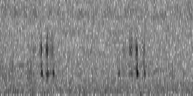
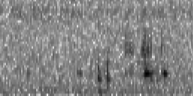
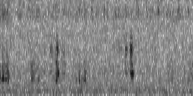
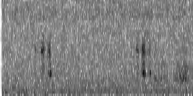

In [18]:
_ = inspect(seed_train, bandpass_range=(0, 2500))

In [19]:
import opensoundscape as opso

## Build database and SongSpace

In [20]:
ss = SongSpace("./Perch2SongSpace", feature_extractor="perch2")

Connecting to existing db at Perch2SongSpace
Connected database has 2,691 embeddings from 672 files.


/Users/SML161/miniconda3/envs/opso_dev/lib/python3.13/site-packages/bioacoustics_model_zoo/perch_v2.py:204: UserWarning: Disabling TensorFlow's XLA compilation (setting tf.config.optimizer.set_jit(False)) because otherwise TF models on Mac hang at runtime as of Tensorflow 2.21.0
  warnings.warn(


In [8]:
import opensoundscape as opso

opso.set_seed(0)

In [23]:
# Embed and register datasets in SongSpace.
ss.ingest_audio(
    seed_train,
    dataset_name="round1_train",
    batch_size=32,
)
ss.ingest_audio(
    validation,
    dataset_name="validation",
    allow_training=False,
    batch_size=32,
)
ss.ingest_audio(
    unlabeled,
    dataset_name="pool_unlabeled",
    batch_size=32,
)

ss.list_datasets()

all samples already have embeddings in the database
all samples already have embeddings in the database
all samples already have embeddings in the database


['round1_train', 'validation', 'pool_unlabeled']

In [24]:
ss.save()

Saved SongSpace to ./Perch2SongSpace with 0 classifiers and 3 datasets.


## Similarity search for similar samples

In [29]:
# Similarity search
matches_for_each_query = ss.similarity_search(seed_train, k=20, exact_search=True)
best_matches = matches_for_each_query.sort_values(
    by="sort_score", ascending=False
).head(20)
# Review and annotate interactively.
_ = annotate(
    best_matches,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

embedding query samples


/Users/SML161/opensoundscape/opensoundscape/ml/cnn.py:2913: UserWarning: The columns of input samples df differ from `model.classes`. Discarding sample df columns.
  warnings.warn(


  0%|          | 0/4 [00:00<?, ?it/s]

I0000 00:00:1775621946.312882 27489383 service.cc:153] XLA service 0x3b81d1640 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775621946.312905 27489383 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1775621946.455994 27489383 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1775621946.761162 27509929 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1775621946.761208 27509929 rsqrt.cc:179] Falling back to 1 / sqrt(x) for f32 false
I0000 00:00:1775621947.079917 27489383 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


performing similarity search for each of 4 query samples


GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

In [ ]:
# ingest labels from the interactive labeling widget
new_pos = best_matches[best_matches["Accept"] == True][
    ["file", "start_time", "end_time"]
].copy()
new_pos[target_model_class] = 1

new_neg = best_matches[best_matches["Reject"] == True][
    ["file", "start_time", "end_time"]
].copy()
new_neg[target_model_class] = 0

search_labels = (
    pd.concat([new_pos, new_neg], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[[target_model_class]]
)

# add these labels to their own dataset in the SongSpace
ss.ingest_audio(
    search_labels,
    dataset_name="search_labels",
    batch_size=32,
    num_workers=0,
)

ss.save()

search_labels[target_model_class].value_counts()

all samples already have embeddings in the database
Saved SongSpace to ./Perch2SongSpace with 0 classifiers and 4 datasets.


RanaSierrae_C
1    11
0     1
Name: count, dtype: int64

## Train first classifier

In [38]:
clf_round1 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train", "search_labels"],
    validation_dataset="validation",
    weak_negatives_proportion=20.0,  # lots of weak negatives, since we have just a few positives!
    weak_negatives_weight=0.01,
    steps=100,
    batch_size=128,
    validation_interval=50,
    logging_interval=50,
)
clf_round1.val_metrics

training classifier for 1 classes with 16 training samples and 536 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 50/100, Loss: 0.138, Val Loss: 1.396
	val AU ROC: 0.795
	val MAP: 0.224
Epoch 100/100, Loss: 0.106, Val Loss: 1.346
	val AU ROC: 0.789
	val MAP: 0.211
Loaded best model with validation loss: 1.346 at step 100 of 100
Training complete


{'loss': 1.3462873458862306,
 'auroc': 0.7890740111073331,
 'map': 0.21066358061976903,
 'per_class_auroc': [0.7890740111073331]}

evaluate it

In [39]:
round1_metrics = ss.evaluate("rana_round1", "validation")
round1_metrics

Finding matching window IDs for samples in label_df...


  0%|          | 0/1 [00:00<?, ?it/s]

{'RanaSierrae_C': {'average_precision': 0.21198593862702766,
  'roc_auc': 0.7905474328459707},
 'macro_average_precision': np.float64(0.21198593862702766),
 'macro_roc_auc': np.float64(0.7905474328459707)}

save the classifier in the SoundScape, if we like it enough

In [40]:
if "rana_round1" in ss.list_classifiers():
    ss.remove_classifier("rana_round1")
ss.add_classifier("rana_round1", clf_round1)
ss.save()

Saved SongSpace to ./Perch2SongSpace with 2 classifiers and 5 datasets.


## Active learning round: review high-scoring candidates

In [41]:
pool_scores = ss.predict_on_dataset(
    classifier_name="rana_round1", dataset_name="pool_unlabeled"
)
# drop samples already labeled
labeled_idx = set(search_labels.index).union(set(seed_train.index))
pool_scores = pool_scores[~pool_scores.index.isin(labeled_idx)]
topk = pool_scores.nlargest(20, target_model_class).reset_index()

# Review and annotate interactively.
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)
topk.head()

Finding matching window IDs for samples in label_df...


  0%|          | 0/3 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

,file,start_time,end_time,RanaSierrae_C,Accept,Reject
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,3.802350,None,None
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,3.649414,None,None
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,3.611421,None,None
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,3.595480,None,None
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,3.529849,None,None


ingest labels

In [35]:
new_pos = topk[topk["Accept"] == True][["file", "start_time", "end_time"]].copy()
new_pos[target_model_class] = 1

new_neg = topk[topk["Reject"] == True][["file", "start_time", "end_time"]].copy()
new_neg[target_model_class] = 0

round2_train = (
    pd.concat([new_pos, new_neg], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[[target_model_class]]
)

ss.ingest_audio(
    round2_train,
    dataset_name="round2_train",
    batch_size=32,
    num_workers=0,
)
ss.save()
round2_train[target_model_class].value_counts()

all samples already have embeddings in the database
Saved SongSpace to ./Perch2SongSpace with 1 classifiers and 5 datasets.


RanaSierrae_C
0    17
1     2
Name: count, dtype: int64

## build a new classifier

In [50]:
clf_round2 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train", "search_labels", "round2_train"],
    validation_dataset="validation",
    weak_negatives_proportion=1.0,
    weak_negatives_weight=0.001,
    steps=200,
    batch_size=128,
    validation_interval=30,
    logging_interval=30,
)
if "rana_round2" in ss.list_classifiers():
    ss.remove_classifier("rana_round2")
ss.add_classifier("rana_round2", clf_round2)

round2_metrics = ss.evaluate("rana_round2", "validation")
round2_metrics

training classifier for 1 classes with 35 training samples and 536 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 30/200, Loss: 0.394, Val Loss: 0.558
	val AU ROC: 0.801
	val MAP: 0.629
Epoch 60/200, Loss: 0.269, Val Loss: 0.445
	val AU ROC: 0.816
	val MAP: 0.642
Epoch 90/200, Loss: 0.204, Val Loss: 0.359
	val AU ROC: 0.831
	val MAP: 0.642
Epoch 120/200, Loss: 0.164, Val Loss: 0.307
	val AU ROC: 0.838
	val MAP: 0.640
Epoch 150/200, Loss: 0.137, Val Loss: 0.275
	val AU ROC: 0.841
	val MAP: 0.638
Epoch 180/200, Loss: 0.118, Val Loss: 0.253
	val AU ROC: 0.843
	val MAP: 0.636
Loaded best model with validation loss: 0.253 at step 180 of 200
Training complete
Finding matching window IDs for samples in label_df...


  0%|          | 0/1 [00:00<?, ?it/s]

{'RanaSierrae_C': {'average_precision': 0.6307563511545158,
  'roc_auc': 0.8437039555706677},
 'macro_average_precision': np.float64(0.6307563511545158),
 'macro_roc_auc': np.float64(0.8437039555706677)}

## Active learning round 2: review high-scoring candidates

In [ ]:
pool_scores = ss.predict_on_dataset(
    classifier_name="rana_round2", dataset_name="pool_unlabeled"
)
# drop samples already labeled
labeled_idx = (
    set(search_labels.index).union(set(seed_train.index)).union(set(round2_train.index))
)
pool_scores = pool_scores[~pool_scores.index.isin(labeled_idx)]
topk = pool_scores.nlargest(20, target_model_class).reset_index()

# Review and annotate interactively.
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)
topk.head()

Finding matching window IDs for samples in label_df...


  0%|          | 0/3 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

,file,start_time,end_time,RanaSierrae_C,Accept,Reject
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,5.022058,None,None
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,4.984020,None,None
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,3.827414,None,None
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,3.278870,None,None
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,9.0,12.0,3.204215,None,None


ingest labels

In [47]:
new_pos = topk[topk["Accept"] == True][["file", "start_time", "end_time"]].copy()
new_pos[target_model_class] = 1

new_neg = topk[topk["Reject"] == True][["file", "start_time", "end_time"]].copy()
new_neg[target_model_class] = 0

round3_train = (
    pd.concat([new_pos, new_neg], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[[target_model_class]]
)

ss.ingest_audio(
    round3_train,
    dataset_name="round3_train",
    batch_size=32,
    num_workers=0,
)
ss.save()
round3_train[target_model_class].value_counts()

all samples already have embeddings in the database
Saved SongSpace to ./Perch2SongSpace with 2 classifiers and 6 datasets.


RanaSierrae_C
1    12
Name: count, dtype: int64

build new classifier

In [49]:
clf_round3 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train", "search_labels", "round2_train", "round3_train"],
    validation_dataset="validation",
    weak_negatives_proportion=1.0,
    weak_negatives_weight=0.001,
    steps=200,
    batch_size=128,
    validation_interval=30,
    logging_interval=30,
)
if "rana_round3" in ss.list_classifiers():
    ss.remove_classifier("rana_round3")
ss.add_classifier("rana_round3", clf_round3)

ss.save()

round3_metrics = ss.evaluate("rana_round3", "validation")
round3_metrics

training classifier for 1 classes with 47 training samples and 536 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 30/200, Loss: 0.361, Val Loss: 0.869
	val AU ROC: 0.770
	val MAP: 0.477
Epoch 60/200, Loss: 0.245, Val Loss: 0.830
	val AU ROC: 0.785
	val MAP: 0.549
Epoch 90/200, Loss: 0.188, Val Loss: 0.728
	val AU ROC: 0.794
	val MAP: 0.595
Epoch 120/200, Loss: 0.151, Val Loss: 0.640
	val AU ROC: 0.798
	val MAP: 0.606
Epoch 150/200, Loss: 0.126, Val Loss: 0.577
	val AU ROC: 0.804
	val MAP: 0.613
Epoch 180/200, Loss: 0.108, Val Loss: 0.532
	val AU ROC: 0.808
	val MAP: 0.612
Loaded best model with validation loss: 0.532 at step 180 of 200
Training complete
Saved SongSpace to ./Perch2SongSpace with 3 classifiers and 6 datasets.
Finding matching window IDs for samples in label_df...


  0%|          | 0/1 [00:00<?, ?it/s]

{'RanaSierrae_C': {'average_precision': 0.6117806699903222,
  'roc_auc': 0.8100419358494844},
 'macro_average_precision': np.float64(0.6117806699903222),
 'macro_roc_auc': np.float64(0.8100419358494844)}

we now have a solid classifier to use for downstream tasks.

## Select clips for manual verification

Use stratified or thresholded selection from the full embedded database.

For example, here we select 20 clips using the most recent classifier

We can also do this in another Python session by re-opening the SongSpace, which will retain all the classifier, labels, and embeddings.

In [ ]:
ss_reloaded = SongSpace.open("./Perch2SongSpace")
print(f"Classifiers: {ss_reloaded.list_classifiers()}")
print(f"Datasets: {ss_reloaded.list_datasets()}")

Classifiers: ['rana_round1', 'rana_round2', 'rana_round3']
Datasets: ['round1_train', 'validation', 'pool_unlabeled', 'search_labels', 'round2_train', 'round3_train']


('2022-06-20', '2022-06-21')



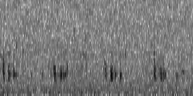
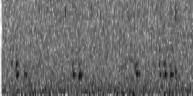

('2022-06-22', '2022-06-23')



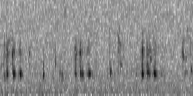
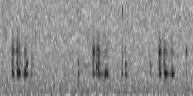

('2022-06-24', '2022-06-25')



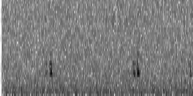
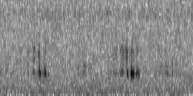

('2022-06-26', '2022-06-27')



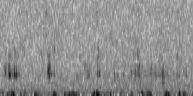
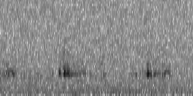

In [ ]:
date_ranges = [
    ("2022-06-20", "2022-06-21"),
    ("2022-06-22", "2022-06-23"),
    ("2022-06-24", "2022-06-25"),
    ("2022-06-26", "2022-06-27"),
]
clips_per_date = []

for i, date_range in enumerate(date_ranges):
    selected = select_from_hoplite(
        ss_reloaded.db,
        ss_reloaded.classifiers["rana_round3"],
        classes=[target_model_class],
        strategy="top_k",
        k=2,
        min_score=0,
        date_range=date_range,
    )
    clips_per_date["visit"] = i + 1
    clips_per_date.append(selected)
    print(date_range)
    inspect(selected, bandpass_range=(0, 2500))

# table ready for Dipper review with stratification by "visit"
clips_for_review = pd.concat(clips_per_date).reset_index(drop=True)

In [126]:
# Optional cleanup
# import shutil
# shutil.rmtree('./songspace_agile_db/')